# Apply an evolved proofreader policy to the whole brain & compare before/after

Takes the **final accepted policy** from a `proofreader_evolve` run, runs it on **all 12 GT skeletons** of brain 789202, and shows what its `merge_labels` repairs did:

1. **Metric comparison** — baseline (no edits) vs edited, per skeleton: split-repair score, `# Splits`, `% Merged Edges`, Edge Accuracy, `# Merges`.
2. **Volume visualization** — pick one SplitSite the policy *repaired*, and render its local receptive field (raw image + fragment skeletons) coloured by **baseline labels vs edited (merged) labels**, side by side, so the repair is visible in 3D context (mirrors `visualization_showcase.ipynb`).

The policy is `propose_edits` from the run's `gen<NN>/heuristics.accepted.py`; it reasons over GT-free fragment geometry only, so it is deployable. Scoring uses the same incremental scorer the evolution loop uses (verified equal to `segmentation_skeleton_metrics.evaluate`).

## 0. Setup — env, paths, parameters

In [1]:
import os
import sys
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Same env / path setup as notebooks/load_skeletons_from_cache.ipynb.
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "../../configs/zihan_gcs_token.json"
os.environ["AWS_EC2_METADATA_DISABLED"] = "true"

# Make proofreader_evolve and the metrics package importable.
PROJ = Path("../..").resolve()                      # exa-spim-agent/
sys.path.insert(0, str(PROJ))
sys.path.insert(0, str(PROJ.parent / "segmentation-skeleton-metrics" / "src"))

from proofreader_evolve.harness import incremental_scoring as inc
from proofreader_evolve.harness import dataset as ds
from proofreader_evolve.harness import candidate as cand
from proofreader_evolve.harness import scoring
from proofreader_evolve.harness.edit_handler import normalize_edits
from agentic_neuron_proofreader.utils import img_util

# --- Parameters -----------------------------------------------------------
BRAIN_ID = "789202"
RUN_NAME = "789202_20260623_232105"          # the evolution run to take the policy from
GEN = None                                     # None -> auto = the LAST accepted generation
                                               # (best policy); or set e.g. "gen20" to pin one.

RUNS = PROJ / "proofreader_evolve" / "runs"
RUN_DIR = RUNS / RUN_NAME

# Auto-resolve GEN to the last ACCEPTED generation from the ledger (the final/best
# policy). The accepted heuristics live in gen<NN>/heuristics.accepted.py.
if GEN is None:
    _ledger = [json.loads(l) for l in (RUN_DIR / "ledger.jsonl").read_text().splitlines() if l.strip()]
    _accepted = [r["generation"] for r in _ledger if r.get("accepted")]
    if not _accepted:
        raise SystemExit(f"no accepted generation in {RUN_DIR/'ledger.jsonl'}")
    GEN = f"gen{max(_accepted):02d}"
    print(f"GEN auto-resolved to last accepted generation: {GEN} "
          f"(accepted gens: {sorted(_accepted)})")

POLICY = RUN_DIR / GEN / "heuristics.accepted.py"
PREPARED = RUN_DIR / f"prepared_{BRAIN_ID}.pkl"
print("policy  :", POLICY, "\n  exists:", POLICY.exists())
print("prepared:", PREPARED, "\n  exists:", PREPARED.exists())

GEN auto-resolved to last accepted generation: gen30 (accepted gens: [1, 2, 3, 5, 6, 8, 9, 12, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 30])
policy  : /allen/programs/mindscope/workgroups/auto-model/zihan.zhang/exaspim-agent/exa-spim-agent/proofreader_evolve/runs/789202_20260623_232105/gen30/heuristics.accepted.py 
  exists: True
prepared: /allen/programs/mindscope/workgroups/auto-model/zihan.zhang/exaspim-agent/exa-spim-agent/proofreader_evolve/runs/789202_20260623_232105/prepared_789202.pkl 
  exists: True


## 1. Load the prepared brain and the fragment graph

`prepared_<brain>.pkl` is the candidate-invariant scoring state (GT graphs + fragment graphs, built once by the run). The cached fragment graph is what the policy enumerates SplitSites over.

In [2]:
prepared = inc.PreparedBrain.load(str(PREPARED))

# Use the SAME fragment cache this run enumerated over. The run records its
# min_cable_length in split.json ("mcl"); older runs predate that field, so fall
# back to 100 (the historical default). Replaying an mcl10 run with mcl100 (or vice
# versa) would enumerate a DIFFERENT candidate stream -> numbers would not match.
_split_cfg = json.loads((RUN_DIR / "split.json").read_text())
MCL = int(_split_cfg.get("mcl", 100))
cache_path = ds.default_cache_path(BRAIN_ID, min_cable_length=MCL)
print(f"fragment cache mcl={MCL} (from split.json): {cache_path}")
fragments_graph, _gt, _payload = ds.load_cached_graphs(cache_path)
all_gt = sorted(prepared.gt_graphs.keys())
print(f"{len(all_gt)} GT skeletons:", all_gt)
print("fragment graph nodes:", fragments_graph.number_of_nodes())

12 GT skeletons: ['N005-789202-SP', 'N006-789202-JG', 'N007-789202-PP', 'N010-789202-JT', 'N011-789202-IG', 'N013-789202-KS', 'N016-789202-HP', 'N018-789202-JM', 'N020-789202-PP', 'N021-789202-HP', 'N022-789202-JG', 'N023-789202-SP']
fragment graph nodes: 4490438


## 1b. Train / held-out split (this run's `split.json`)

Which GT neurons the reviser saw during evolution (TRAIN) vs which only the gate scored (HELD-OUT). The policy never trained on the held-out skeletons, so repairs there are the honest generalization signal.

In [3]:
# Log the train / held-out split for this run (from split.json).
_split = json.loads((RUN_DIR / "split.json").read_text())
_pb = _split["per_brain"][BRAIN_ID]
train_names = sorted(_pb["train"])
heldout_names = sorted(_pb["heldout"])
print(f"TRAIN  ({len(train_names)}) — reviser saw these during evolution:")
for n in train_names:
    print("   ", n)
print(f"HELD-OUT ({len(heldout_names)}) — gate-scored only, never trained on:")
for n in heldout_names:
    print("   ", n)
# sanity: together they should be exactly the 12 scored GT skeletons
assert set(train_names) | set(heldout_names) == set(all_gt), "split.json != scored GT set"

TRAIN  (6) — reviser saw these during evolution:
    N006-789202-JG
    N011-789202-IG
    N016-789202-HP
    N020-789202-PP
    N022-789202-JG
    N023-789202-SP
HELD-OUT (6) — gate-scored only, never trained on:
    N005-789202-SP
    N007-789202-PP
    N010-789202-JT
    N013-789202-KS
    N018-789202-JM
    N021-789202-HP


## 2. Run the final policy on the WHOLE brain → edits

We reproduce `candidate.run_candidate`'s edit-production path: enumerate SplitSites from the fragment graph (using the policy's own `ENUM_PARAMS`), call `propose_edits`, and keep the `merge_labels` edits. No GT is given to the policy.

> **Image reader matters.** This run scored held-out *with a live image reader*, and the final policy gates most of its recall on `gap_bridge_evidence`. The cell below builds the SAME `LazyImagePatchReader` the evolution loop used (needs GCS), so the edits reproduce the policy's real behaviour. If the reader can't be built it falls back to geometry-only and warns — in that case the counts are a *subset* and will not match the run's held-out split-repair score.

In [4]:
propose_edits, policy_module = cand._load_policy(str(POLICY))

raw_enum = getattr(policy_module, "ENUM_PARAMS", None)
raw_enum = {**raw_enum} if isinstance(raw_enum, dict) else {}
raw_enum.setdefault("max_gap_um", 15.0)
enum_params = ds.resolve_enum_params(raw_enum)

# splits-only style enumeration (the run was splits-only): SplitSites only.
split_sites, merge_sites, _split_stats = cand._enumerate_sites_cached(
    fragments_graph, enum_params, enumerate_merges=False)
sites = list(split_sites) + list(merge_sites)

# IMAGE READER — MUST match the evolution loop. The run 789202_20260623_232105
# scored held-out WITH a live image reader (run_evolution passes
# image_reader=bc.image_reader to run_candidate), and the gen30 policy gates most of
# its recall on gap_bridge_evidence. Replaying with read_image_patch=None silently
# disables those tiers, so the policy emits only its narrow geometry-only subset
# (e.g. ~123 edits / held-out correct ~16 instead of ~2153 / 259). We build the SAME
# LazyImagePatchReader the loop uses so this notebook reproduces the real policy.
# (Needs GCS access; if it cannot be built we fall back to None and WARN loudly that
# the numbers are the geometry-only subset, not the policy's true behaviour.)
import sys as _sys
_sys.path.insert(0, str(PROJ / "scripts"))
try:
    from proofreader_evolve.harness.image_features import LazyImagePatchReader
    from dataset_config import get_img_path
    _prefixes = str(PROJ / "configs" / "exaspim_image_prefixes.json")
    _img_path = get_img_path(BRAIN_ID, prefixes_path=_prefixes)
    image_reader = LazyImagePatchReader(_img_path, fragments_graph)
    print(f"image reader ENABLED (matches evolution): {_img_path}")
except Exception as _e:
    image_reader = None
    print(f"[WARN] could NOT build image reader ({_e}).\n"
          f"       Falling back to read_image_patch=None: the policy's image-gated\n"
          f"       tiers are DISABLED, so `edits` below is only its geometry-only\n"
          f"       subset and will NOT match the evolution run's held-out score.")

ctx = {
    "max_gap_um": enum_params["max_gap_um"], "enum_params": dict(enum_params),
    "fragments_graph": fragments_graph, "n_split_sites": len(split_sites),
    "n_merge_sites": len(merge_sites),
    "node_radius": getattr(fragments_graph, "node_radius", None),
    "read_image_patch": image_reader,
}
edits = normalize_edits(propose_edits(sites, ctx))
edits = [e for e in edits if e.get("kind") == "merge_labels"]  # splits-only
print(f"enumerated {len(split_sites)} SplitSites; policy emitted {len(edits)} merge_labels edits"
      + ("" if image_reader is not None else "  [GEOMETRY-ONLY — image disabled]"))

image reader ENABLED (matches evolution): s3://aind-open-data/exaSPIM_789202_2026-02-03_15-09-59_processed_2026-02-15_23-47-18/fusion/fused.zarr/0
enumerated 5000 SplitSites; policy emitted 2153 merge_labels edits


## 3. Score baseline (no edits) vs edited — all 12 skeletons

`gt_swc_names=None` scores every GT skeleton. The incremental scorer applies the `merge_labels` edits as a label-equivalence collapse and recomputes the real metrics.

In [5]:
base = inc.score_incremental(prepared, label_pairs=None, gt_swc_names=None, verbose=False)
edited = inc.score_incremental(prepared, edits=edits, gt_swc_names=None, verbose=False)
print(f"baseline scored in {base.seconds:.1f}s; edited scored in {edited.seconds:.1f}s")

# Split-repair classification of the edits against the FULL-brain label->neuron map
# (here we use all 12 GT skeletons, so it is the deployable 'how many real splits did
# we repair' count, not a leak-free gate signal).
label_gt_map = inc.label_gt_counts(prepared, gt_names=None)
repair = inc.classify_merge_edits(edits, label_gt_map)
print(f"split-repair on all GT: correct={repair['correct']} false={repair['false']} "
      f"unscored={repair['unscored']} (score = {repair['correct']-repair['false']})")

baseline scored in 241.5s; edited scored in 248.2s
split-repair on all GT: correct=475 false=2 unscored=1676 (score = 473)


## 4. Per-skeleton metric comparison (baseline vs edited)

In [6]:
COLS = ["Edge Accuracy", "% Merged Edges", "# Merges", "% Split Edges", "# Splits", "% Omit Edges"]
b = base.per_swc[COLS]
e = edited.per_swc.reindex(b.index)[COLS]
delta = (e - b).add_prefix("d")

# `edit-caused merges`: per GT skeleton, how many merge sites THIS revision
# introduced (its fused class unifies >=2 raw labels -> Caused_By_Edit). This is a
# CAUSE column that ACCOMPANIES the official net change `d# Merges` (in delta): the
# official count can read ~0 even when the policy created many cross-neuron fusions,
# because new merges cancel pre-existing ones in the net (e.g. N013: d# Merges 0 but
# 26 edit-caused). So we report BOTH: `d# Merges` (official, signed net change) and
# `edit-caused merges` (the absolute number this policy is responsible for). The
# baseline has none (identity relabel fuses nothing), so an absolute count is the
# meaningful form — no base/delta variants.
def _edit_caused_merges(score_result):
    ms = getattr(score_result, "merge_sites", None)
    if ms is None or len(ms) == 0 or "GroundTruth_ID" not in ms.columns \
            or "Caused_By_Edit" not in ms.columns:
        return pd.Series(0, index=b.index, dtype=int)
    rows = ms[ms["Caused_By_Edit"]]
    return rows["GroundTruth_ID"].value_counts().reindex(b.index).fillna(0).astype(int)

edit_caused_merges = _edit_caused_merges(edited)

comp = pd.concat([b.add_prefix("base "), e.add_prefix("edit "), delta], axis=1)
# One companion column, placed right after the metric deltas.
comp["edit-caused merges"] = edit_caused_merges

comp.loc["WEIGHTED MEAN"] = {
    **{f"base {c}": scoring._weighted_avg(base.per_swc, c) for c in COLS},
    **{f"edit {c}": scoring._weighted_avg(edited.per_swc, c) for c in COLS},
    **{f"d{c}": scoring._weighted_avg(edited.per_swc, c) - scoring._weighted_avg(base.per_swc, c) for c in COLS},
}
# edit-caused merges is a COUNT, not a run-length-weighted metric, so the summary
# row gets the TOTAL across skeletons (a weighted mean of a count is meaningless).
comp.loc["WEIGHTED MEAN", "edit-caused merges"] = int(edit_caused_merges.sum())

pd.set_option("display.width", 200, "display.max_columns", 40)
comp.round(3)

,base Edge Accuracy,base % Merged Edges,base # Merges,base % Split Edges,base # Splits,base % Omit Edges,edit Edge Accuracy,edit % Merged Edges,edit # Merges,edit % Split Edges,edit # Splits,edit % Omit Edges,dEdge Accuracy,d% Merged Edges,d# Merges,d% Split Edges,d# Splits,d% Omit Edges,edit-caused merges
N005-789202-SP,86.980,8.648,9.000,0.422,1061.000,3.948,83.120,12.584,11.000,0.405,1004.000,3.890,-3.860,3.936,2.000,-0.016,-57.000,-0.058,8.0
N006-789202-JG,83.880,14.680,11.000,0.285,1200.000,1.156,82.360,16.203,11.000,0.279,1164.000,1.154,-1.520,1.523,0.000,-0.007,-36.000,-0.002,4.0
N007-789202-PP,91.960,2.314,5.000,0.371,582.000,5.355,92.030,2.314,5.000,0.350,546.000,5.310,0.070,0.000,0.000,-0.021,-36.000,-0.044,0.0
N010-789202-JT,90.040,3.984,3.000,0.937,1390.000,5.037,89.760,4.312,3.000,0.924,1362.000,5.009,-0.280,0.328,0.000,-0.013,-28.000,-0.028,1.0
N011-789202-IG,94.130,1.796,1.000,0.482,675.000,3.594,94.170,1.796,1.000,0.460,644.000,3.575,0.040,0.000,0.000,-0.022,-31.000,-0.019,1.0
N013-789202-KS,56.910,41.041,36.000,0.212,782.000,1.838,50.950,47.056,37.000,0.201,718.000,1.797,-5.960,6.016,1.000,-0.012,-64.000,-0.040,27.0
N016-789202-HP,84.250,14.954,11.000,0.177,641.000,0.621,71.060,28.152,11.000,0.172,610.000,0.619,-13.190,13.198,0.000,-0.005,-31.000,-0.002,3.0
N018-789202-JM,56.710,42.930,4.000,0.116,564.000,0.244,52.480,47.170,5.000,0.108,514.000,0.241,-4.230,4.239,1.000,-0.008,-50.000,-0.003,4.0
N020-789202-PP,91.030,7.863,2.000,0.291,357.000,0.817,90.430,8.469,2.000,0.284,344.000,0.817,-0.600,0.606,0.000,-0.007,-13.000,0.000,2.0
N021-789202-HP,94.560,3.209,5.000,0.231,616.000,1.999,91.530,6.273,5.000,0.225,592.000,1.972,-3.030,3.064,0.000,-0.006,-24.000,-0.026,4.0


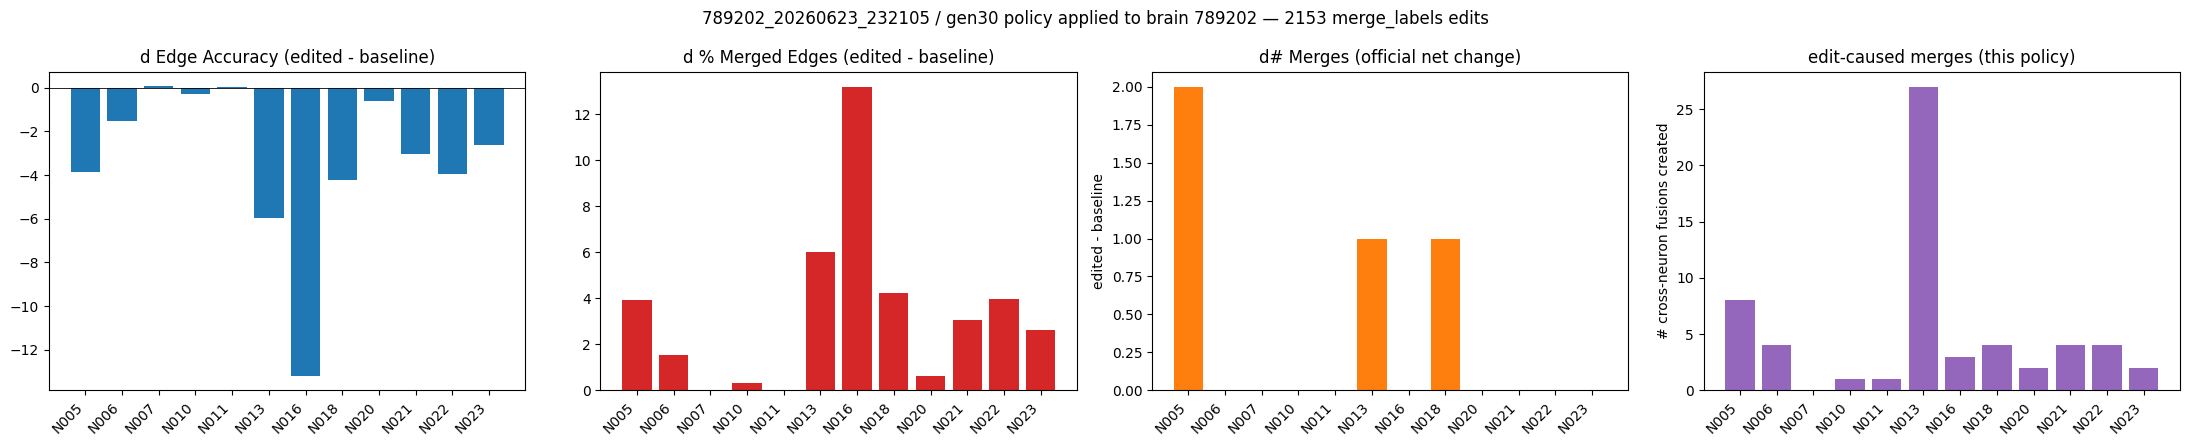

saved per-skeleton deltas -> /allen/programs/mindscope/workgroups/auto-model/zihan.zhang/exaspim-agent/exa-spim-agent/proofreader_evolve/runs/789202_20260623_232105/policy_analysis/per_skeleton_deltas_gen30_789202.csv
saved merge comparison  -> /allen/programs/mindscope/workgroups/auto-model/zihan.zhang/exaspim-agent/exa-spim-agent/proofreader_evolve/runs/789202_20260623_232105/policy_analysis/merge_comparison_gen30_789202.csv


In [7]:
# Visual summary: per-skeleton dEdgeAcc and d%MergedEdges (the merge-error component).
# Use delta.index (defined in the metric-table cell) rather than a bare `b`,
# which other cells reuse as a loop/throwaway variable.
names = list(delta.index)
x = np.arange(len(names))
_xt = [n.split('-')[0] for n in names]
# Four panels: combined-quality delta, merge-error % delta (effect), and the TWO
# merge-count views side by side so both are shown explicitly:
#   (3) d# Merges       — OFFICIAL signed net change (the reported metric);
#   (4) edit-caused merges — how many cross-neuron fusions THIS policy created
#                         (the cause d# Merges can hide when new merges cancel
#                          pre-existing ones, e.g. N013: d# Merges 0 but 26 caused).
fig, axes = plt.subplots(1, 4, figsize=(22, 4.5))
axes[0].bar(x, delta.loc[names, "dEdge Accuracy"], color="#1f77b4")
axes[0].axhline(0, color="k", lw=0.6); axes[0].set_title("d Edge Accuracy (edited - baseline)")
axes[0].set_xticks(x); axes[0].set_xticklabels(_xt, rotation=45, ha="right")
axes[1].bar(x, delta.loc[names, "d% Merged Edges"], color="#d62728")
axes[1].axhline(0, color="k", lw=0.6); axes[1].set_title("d % Merged Edges (edited - baseline)")
axes[1].set_xticks(x); axes[1].set_xticklabels(_xt, rotation=45, ha="right")
axes[2].bar(x, delta.loc[names, "d# Merges"], color="#ff7f0e")
axes[2].axhline(0, color="k", lw=0.6); axes[2].set_title("d# Merges (official net change)")
axes[2].set_ylabel("edited - baseline")
axes[2].set_xticks(x); axes[2].set_xticklabels(_xt, rotation=45, ha="right")
axes[3].bar(x, comp.loc[names, "edit-caused merges"], color="#9467bd")
axes[3].set_title("edit-caused merges (this policy)")
axes[3].set_ylabel("# cross-neuron fusions created")
axes[3].set_xticks(x); axes[3].set_xticklabels(_xt, rotation=45, ha="right")
fig.suptitle(f"{RUN_NAME} / {GEN} policy applied to brain {BRAIN_ID} — {len(edits)} merge_labels edits")
fig.tight_layout(); plt.show()

# --- SAVE per-skeleton metric deltas + this figure to the run folder ---
# Reloadable artifacts under runs/<run>/policy_analysis/. The CSV is the full
# base/edit/delta table (`comp`, incl. the WEIGHTED MEAN row). Figure is shown inline,
# not saved.
_ana_dir = RUN_DIR / "policy_analysis"
_ana_dir.mkdir(parents=True, exist_ok=True)
_tag = f"{GEN}_{BRAIN_ID}"
_per_skel_csv = _ana_dir / f"per_skeleton_deltas_{_tag}.csv"
comp.round(6).to_csv(_per_skel_csv)
print(f"saved per-skeleton deltas -> {_per_skel_csv}")

# Also save a FOCUSED merge-comparison CSV: the two merge-count views side by side
# (official net change vs edit-caused), plus base/edit # Merges and d% Merged Edges
# for context. Small and self-explanatory; the full table is in the CSV above.
_merge_cols = [c for c in ["base # Merges", "edit # Merges", "d# Merges",
                           "edit-caused merges", "d% Merged Edges"] if c in comp.columns]
_merge_csv = _ana_dir / f"merge_comparison_{_tag}.csv"
comp[_merge_cols].round(4).to_csv(_merge_csv)
print(f"saved merge comparison  -> {_merge_csv}")

## 5. Pick a few repaired SplitSites to visualize

A **repaired** SplitSite = an enumerated SplitSite whose two fragment labels (a) the policy actually merged, and (b) belong to the SAME GT neuron (a real split it correctly closed). We pick `N_EXAMPLES` of them deterministically, spread evenly across the gap range (so the examples differ); each becomes one before/after panel below.

`RESTRICT_TO` (set in cell 0) limits which GT neurons the shown repairs may sit on — `None` (all 12), `"train"`, or `"heldout"` — using the run's `split.json`. It affects only **which examples are displayed**, never the scoring or the edits.

In [8]:
SEED = np.random.randint(0,10000)                                      # which repaired SplitSites to visualize (deterministic pick)
N_EXAMPLES = 10                                 # how many repaired SplitSites to visualize
RESTRICT_TO = None                             # which GT neurons the visualized repairs may sit on:
                                               #   None      -> all 12 GT skeletons (no restriction)
                                               #   "train"   -> only this run's TRAIN skeletons
                                               #   "heldout" -> only this run's HELD-OUT skeletons
                                               # (reads the run's split.json; affects ONLY which
                                               #  examples are shown, NOT scoring or the edits.)

In [9]:
def _pair_key(a, b):
    a, b = str(a), str(b); return (a, b) if a <= b else (b, a)

accepted = {_pair_key(e["label_a"], e["label_b"]) for e in edits}

def _dominant(lbl):
    c = label_gt_map.get(str(lbl)); return max(c, key=c.get) if c else None

# RESTRICT_TO -> the set of GT skeleton names a repair is allowed to sit on. Reads the
# run's split.json (the SAME train/held-out partition the evolution used). None = all.
allowed_neurons = None
if RESTRICT_TO is not None:
    split = json.loads((RUN_DIR / "split.json").read_text())
    per_brain = split["per_brain"][BRAIN_ID]
    key = {"train": "train", "heldout": "heldout"}[RESTRICT_TO]
    allowed_neurons = set(per_brain[key])
    print(f"RESTRICT_TO={RESTRICT_TO!r}: {len(allowed_neurons)} GT skeletons -> {sorted(allowed_neurons)}")
else:
    print("RESTRICT_TO=None: any of the 12 GT skeletons")

repaired = []  # SplitSites the policy merged AND that are real splits (same GT neuron)
for s in split_sites:
    la, lb = str(s.label_a), str(s.label_b)
    if _pair_key(la, lb) not in accepted:
        continue
    da, db = _dominant(la), _dominant(lb)
    if da is None or da != db:
        continue
    if allowed_neurons is not None and da not in allowed_neurons:
        continue                      # repair sits on a neuron outside the requested split
    repaired.append(s)
print(f"{len(repaired)} repaired real-split SplitSites available"
      + (f" on {RESTRICT_TO} neurons" if RESTRICT_TO else ""))
assert repaired, "no repaired SplitSites match the filter — try RESTRICT_TO=None or another GEN"

# Deterministic, spread-out pick: sort by gap and take N_EXAMPLES evenly-spaced
# samples from the middle band (skip the extreme-near/extreme-far tails). Shift by
# SEED to get a different (still reproducible) set.
repaired.sort(key=lambda s: s.gap_um)
band = repaired[len(repaired)//10 : 9*len(repaired)//10] or repaired
idxs = [int((k + 0.5) * len(band) / N_EXAMPLES) + SEED for k in range(N_EXAMPLES)]
sites_to_show = [band[i % len(band)] for i in idxs]

for k, s in enumerate(sites_to_show):
    c = tuple((np.asarray(s.xyz_a, float) + np.asarray(s.xyz_b, float)) / 2.0)
    print(f"  example {k}: {s.label_a} <-> {s.label_b}, gap {s.gap_um:.2f} um, "
          f"GT neuron {_dominant(s.label_a)}, center(um) {tuple(round(v,1) for v in c)}")

RESTRICT_TO=None: any of the 12 GT skeletons
475 repaired real-split SplitSites available
  example 0: 747765650 <-> 645191523, gap 3.16 um, GT neuron N021-789202-HP, center(um) (np.float64(28917.5), np.float64(25125.0), np.float64(12850.5))
  example 1: 510791659 <-> 496076613, gap 3.32 um, GT neuron N023-789202-SP, center(um) (np.float64(23867.5), np.float64(21873.5), np.float64(8645.5))
  example 2: 612295313 <-> 612222610, gap 1.90 um, GT neuron N005-789202-SP, center(um) (np.float64(36818.5), np.float64(18484.9), np.float64(10783.8))
  example 3: 697029483 <-> 696956772, gap 2.22 um, GT neuron N006-789202-JG, center(um) (np.float64(32877.6), np.float64(11242.9), np.float64(12206.5))
  example 4: 302163737 <-> 302236442, gap 2.24 um, GT neuron N022-789202-JG, center(um) (np.float64(20707.0), np.float64(16649.5), np.float64(5303.0))
  example 5: 569343503 <-> 569343511, gap 2.45 um, GT neuron N013-789202-KS, center(um) (np.float64(10432.5), np.float64(21349.5), np.float64(9802.0))
 

## 6. Visualize the repaired regions — MIP + GT + fragments, BEFORE vs AFTER

For each chosen SplitSite (3 in total), the same panels as `visualization_showcase.ipynb`:

1. **Raw image MIP** (XY / XZ / YZ) — the fluorescence the policy implicitly trusted at the gap.
2. **GT skeleton** (lime) — shown **once** as the truth reference.
3. **Fragments BEFORE** — coloured by raw connected component: the two fragments at the site are **different colours** (the split the segmentation made).
4. **Fragments AFTER** — coloured by the policy's edited equivalence class: the merged pair is now **one colour** (the repair).

Skeletons are proper edge MIPs (lines, not dots) via `plot_skeleton_mips`.

In [10]:
PATCH = 160                                   # receptive-field cube side (voxels) for the volume viz

In [11]:
from agentic_neuron_proofreader.data_modules.datasets import BrainDataset
from proofreader_evolve.harness.edit_handler import EditHandler

# Same *_add.pkl cache visualization_showcase uses: agentic SkeletonGraph
# (nodes_in_patch / edges_in_patch / node_component_id / node_segment_id) + GCS reader.
#
# GUARD: the visualization cache (_add) MUST match the scoring/candidate cache
# (cell 4's `cache_path`) on min_cable_length. They are TWO separate pickles, so a
# stale or mismatched _add file would silently show fragments whose ids/components
# differ from the ones the policy actually scored/edited -> colours wrong, repairs
# missing, no error. Fail loudly here instead.
from pathlib import Path as _Path
add_cache = f"../../cache/dataset_cache_{BRAIN_ID}_mcl{MCL}_add.pkl"
assert _Path(add_cache).exists(), (
    f"visualization cache not found: {add_cache}\n"
    f"  build it (load_skeletons.ipynb with the _add extras) or fix BRAIN_ID/mcl.")
_mcl_score = int(re.search(r"_mcl(\d+)", _Path(cache_path).name).group(1))
_mcl_viz   = int(re.search(r"_mcl(\d+)", _Path(add_cache).name).group(1))
assert _mcl_viz == _mcl_score, (
    f"cache mismatch: scoring/candidate cache is mcl{_mcl_score} ({_Path(cache_path).name}) "
    f"but visualization cache is mcl{_mcl_viz} ({_Path(add_cache).name}). They must share the "
    f"same min_cable_length or the visualized fragments will not match the scored ones.")
bd = BrainDataset.load_from_cache(add_cache)
gt_viz, fr_viz = bd.gt_graph, bd.fragments_graph
# Cross-check the actual fragment universes agree (defends against a same-named but
# differently-built _add cache): the scored graph and the viz graph should cover the
# same segment ids. Warn (not fail) if they drift, since viz is non-scoring.
try:
    _seg_score = {str(fragments_graph.node_segment_id(n)) for n in fragments_graph.nodes}
    _seg_viz   = {str(fr_viz.node_segment_id(n)) for n in fr_viz.nodes}
    _missing = _seg_score - _seg_viz
    if _missing:
        print(f"[WARN] {len(_missing)} segment id(s) the policy scored are ABSENT from the "
              f"visualization cache (e.g. {sorted(_missing)[:5]}) — those repairs cannot be "
              f"drawn. Likely the two caches were built differently.")
    else:
        print(f"cache check OK: viz covers all {len(_seg_score)} scored segment ids (mcl{_mcl_score}).")
except Exception as _e:
    print(f"[WARN] could not cross-check fragment universes ({_e}); proceeding.")
aniso = gt_viz.anisotropy
handler = EditHandler(edits, all_labels=prepared.all_fragment_labels)
PATCH_SHAPE = (PATCH, PATCH, PATCH)

SHOW_SLICES = True                              # also show multi-depth raw-image slices
SLICE_FRACTIONS = (0.2, 0.4, 0.5, 0.6, 0.8)     # depth fractions for plot_slices rows


def plot_slices(patch, title="", fractions=SLICE_FRACTIONS):
    """Several single-plane SLICES at increasing depth, in ONE figure (from
    visualization_showcase.ipynb). Unlike a MIP (which maxes over the whole depth),
    each panel is one true imaging layer ``patch[int(f*depth)]``. Rows = depth
    fraction along the projection axis; columns = XY / XZ / YZ."""
    nz, ny, nx = patch.shape
    names = ["XY (vary z)", "XZ (vary y)", "YZ (vary x)"]
    sizes = [nz, ny, nx]
    vmax = np.percentile(patch, 99.9)
    nrows = len(fractions)
    fig, axs = plt.subplots(nrows, 3, figsize=(10, 3.2 * nrows))
    axs = np.atleast_2d(axs)
    for r, frac in enumerate(fractions):
        idx = [min(int(frac * s), s - 1) for s in sizes]
        planes = [patch[idx[0]], patch[:, idx[1]], patch[:, :, idx[2]]]
        for c, (ax, plane, nm) in enumerate(zip(axs[r], planes, names)):
            ax.imshow(plane, cmap="gray", vmax=vmax)
            ax.set_xticks([]); ax.set_yticks([])
            if r == 0:
                ax.set_title(nm, fontsize=14)
            if c == 0:
                ax.set_ylabel(f"{int(frac * 100)}% depth\n(plane {idx[0]})", fontsize=12)
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def show_example(site):
    """Render ONE repaired SplitSite the visualization_showcase way:
       (1) raw-image MIP (XY/XZ/YZ),
       (1b) raw-image multi-depth SLICES (when SHOW_SLICES),
       (2) GT skeleton MIPs (lime) — shown ONCE, the truth reference,
       (3) fragment skeleton MIPs BEFORE the edit (coloured by raw component),
       (4) fragment skeleton MIPs AFTER  the edit (coloured by merged class).
    The two fragments the policy merged are DIFFERENT colours before and ONE colour
    after; GT is the same in both, so we draw it only once.
    """
    center_um = tuple((np.asarray(site.xyz_a, float) + np.asarray(site.xyz_b, float)) / 2.0)
    center_voxel = img_util.to_voxels(center_um, aniso)          # (z, y, x)
    offset = tuple(c - s // 2 for c, s in zip(center_voxel, PATCH_SHAPE))
    img_patch = np.squeeze(bd.img.read(center_voxel, PATCH_SHAPE))

    gt_nodes, gt_ncomp = gt_viz.nodes_in_patch(offset, PATCH_SHAPE, return_components=True)
    gt_edges, gt_ecomp = gt_viz.edges_in_patch(offset, PATCH_SHAPE, return_components=True)
    fr_nodes, fr_nid, fr_ncomp = fr_viz.nodes_in_patch(
        offset, PATCH_SHAPE, return_ids=True, return_components=True)
    fr_edges, fr_ecomp = fr_viz.edges_in_patch(offset, PATCH_SHAPE, return_components=True)

    # Remap fragment component-id -> the policy's edited equivalence class, so the
    # merged pair shares a colour AFTER. (BEFORE keeps the raw component id.)
    comp_rep = {}
    for nid, comp in zip(fr_nid, fr_ncomp):
        comp_rep.setdefault(int(comp), int(nid))
    comp_edited = {c: handler.get(str(fr_viz.node_segment_id(rep))) for c, rep in comp_rep.items()}
    cls_int = {cls: i for i, cls in enumerate(sorted(set(comp_edited.values())))}
    def to_after(arr):
        return np.array([cls_int[comp_edited[int(c)]] for c in arr], dtype=int)
    fr_ncomp_after, fr_ecomp_after = to_after(fr_ncomp), to_after(fr_ecomp)

    tag = (f"SplitSite {site.label_a}+{site.label_b}  gap {site.gap_um:.2f} µm  "
           f"GT {_dominant(site.label_a)}  @ {tuple(round(v,1) for v in center_um)} µm")
    print(f"\n=== {tag} ===")
    print(f"GT nodes/edges in patch: {len(gt_nodes)}/{len(gt_edges)}   "
          f"fragment nodes/edges: {len(fr_nodes)}/{len(fr_edges)}")

    print("Raw image (MIP):")
    img_util.plot_mips(img_patch)
    if SHOW_SLICES:
        print(f"Raw image (slices at {[int(f*100) for f in SLICE_FRACTIONS]}% depth):")
        plot_slices(img_patch)

    print("GT skeleton (lime) — truth reference, shown once:")
    img_util.plot_skeleton_mips({
        "GT": {"nodes": gt_nodes, "node_components": gt_ncomp,
               "edges": gt_edges, "components": gt_ecomp, "color": "lime"},
    }, PATCH_SHAPE, separate_rows=True)

    print("Fragments BEFORE — by raw connected component (the split = two colours):")
    img_util.plot_skeleton_mips({
        "Fragments (before)": {"nodes": fr_nodes, "node_components": fr_ncomp,
                               "edges": fr_edges, "components": fr_ecomp, "color": "cyan"},
    }, PATCH_SHAPE, separate_rows=True)

    print("Fragments AFTER — by policy's merged class (the repair = one colour):")
    img_util.plot_skeleton_mips({
        "Fragments (after)": {"nodes": fr_nodes, "node_components": fr_ncomp_after,
                              "edges": fr_edges, "components": fr_ecomp_after, "color": "cyan"},
    }, PATCH_SHAPE, separate_rows=True)

print("setup ready: show_example()")

cache check OK: viz covers all 59186 scored segment ids (mcl100).
setup ready: show_example()


In [12]:
from matplotlib.backends.backend_pdf import PdfPages

# Render each chosen example and save ITS figures (raw MIP, depth slices, GT,
# fragments before/after) into its OWN multi-page PDF, under a dedicated subfolder
# of this run: runs/<run>/policy_viz/. One site -> one PDF (5 pages).
#
# The showcase plotters call plt.show() internally; under the Jupyter INLINE backend
# that *closes* each figure, so we'd collect none. We temporarily replace plt.show
# with a no-op so figures persist until written, then restore it. (Figures go to the
# PDFs, not inline — open the PDFs to view.)
VIZ_DIR = RUN_DIR / "policy_viz"
VIZ_DIR.mkdir(parents=True, exist_ok=True)

_real_show = plt.show
plt.show = lambda *a, **k: None
try:
    for k, s in enumerate(sites_to_show):
        plt.close("all")                          # isolate THIS site's figures
        show_example(s)
        figs = [plt.figure(num) for num in plt.get_fignums()]
        # One PDF per site: index + label pair + GT neuron (no seed in the name).
        name = f"ex{k:02d}_{s.label_a}-{s.label_b}_{_dominant(s.label_a)}.pdf"
        pdf_path = VIZ_DIR / name
        with PdfPages(pdf_path) as pdf:
            for f in figs:
                pdf.savefig(f, bbox_inches="tight")
        print(f"  saved {len(figs)} figures -> {pdf_path}")
finally:
    plt.show = _real_show
    plt.close("all")
print(f"\ndone: {len(sites_to_show)} per-site PDFs in {VIZ_DIR}")


=== SplitSite 747765650+645191523  gap 3.16 µm  GT N021-789202-HP  @ (np.float64(28917.5), np.float64(25125.0), np.float64(12850.5)) µm ===
GT nodes/edges in patch: 87/84   fragment nodes/edges: 73/69
Raw image (MIP):
Raw image (slices at [20, 40, 50, 60, 80]% depth):
GT skeleton (lime) — truth reference, shown once:
Fragments BEFORE — by raw connected component (the split = two colours):
Fragments AFTER — by policy's merged class (the repair = one colour):
  saved 5 figures -> /allen/programs/mindscope/workgroups/auto-model/zihan.zhang/exaspim-agent/exa-spim-agent/proofreader_evolve/runs/789202_20260623_232105/policy_viz/ex00_747765650-645191523_N021-789202-HP.pdf

=== SplitSite 510791659+496076613  gap 3.32 µm  GT N023-789202-SP  @ (np.float64(23867.5), np.float64(21873.5), np.float64(8645.5)) µm ===
GT nodes/edges in patch: 82/81   fragment nodes/edges: 68/65
Raw image (MIP):
Raw image (slices at [20, 40, 50, 60, 80]% depth):
GT skeleton (lime) — truth reference, shown once:
Fragme

## 7. (optional) Export the edits for this brain

The lightweight, auditable artifact: every `merge_labels` pair the policy proposed. (We do not materialize a repaired voxel volume — edits are a label-equivalence overlay, see `proofreader_evolve/todo.md`.)

In [13]:
# out = Path(f"./{RUN_NAME}_{GEN}_{BRAIN_ID}_edits.json")
# out.write_text(json.dumps({
#     "run": RUN_NAME, "generation": GEN, "brain": BRAIN_ID,
#     "n_edits": len(edits),
#     "split_repair": {k: repair[k] for k in ("correct", "false", "unscored")},
#     "edits": edits,
# }, indent=2))
# print("wrote", out, f"({len(edits)} edits)")

## 8. Split-error repair coverage — fixed vs remaining

How many split errors did this policy repair, and how many remain? Reported in **two
units** so it ties out against the evolution loop:

- **(A) per-edit** — every `merge_labels` edit counts (union-find means one repaired
  neuron spans many merge edges). This is the dense number the gate optimizes; its
  **held-out `correct`** reproduces `heldout_split_repair_score` in `ledger.jsonl`.
- **(B) per-site** — distinct reachable split errors (deduped by label-pair): *how
  many places* were fixed vs. left unrepaired. This is the smaller, intuitive count.

Each is split **train vs held-out** using the run's own per-split label→neuron maps
(the SAME scope the evolution used), so (A)'s held-out column matches the gate.

**Ceiling caveat:** *reachable* = within the candidate stream (the `mcl`-filtered
fragment cache). Split errors on sub-`min_cable_length` fragments are not enumerated,
so they sit outside BOTH denominators — a recall ceiling, not a miss.

In [14]:
# Split-error repair coverage, reported in BOTH units so it ties out against the
# evolution loop:
#   (A) PER-EDIT  (matches the gate's split-repair score in ledger.jsonl): every
#       merge_labels edit counts; union-find means one repaired neuron yields many
#       edges, so this is the large, dense number the gate optimizes.
#   (B) PER-SITE  (deduped by label-pair): how many DISTINCT reachable split errors
#       were closed — the smaller 'how many places did we fix' number.
# We further split each by train vs held-out, using the run's OWN per-split maps so
# (A)'s held-out column reproduces ledger 'heldout_split_repair_score'.

_split = json.loads((RUN_DIR / "split.json").read_text())
_per_brain = _split["per_brain"][BRAIN_ID]
_train_names, _heldout_names = _per_brain["train"], _per_brain["heldout"]
_train_set, _heldout_set = set(_train_names), set(_heldout_names)

# Per-split label->neuron maps (SAME scope the evolution used): a label is only
# 'dominant on a train neuron' within the train map, etc. This is what makes the
# per-edit held-out count equal the gate's number (full-brain would over-count).
_train_map   = inc.label_gt_counts(prepared, gt_names=_train_names)
_heldout_map = inc.label_gt_counts(prepared, gt_names=_heldout_names)

# ---------- (A) PER-EDIT, per-split (reproduces the gate's classify_merge_edits) ----
_rep_train   = inc.classify_merge_edits(edits, _train_map)
_rep_heldout = inc.classify_merge_edits(edits, _heldout_map)

# ---------- (B) PER-SITE, deduped reachable real splits (fixed vs remaining) --------
# candidate_split_sites already keeps ONE site per unordered label-pair, so iterating
# split_sites is per-distinct-pair. 'dominant neuron' uses the per-split maps so a
# pair is bucketed train/held-out consistently with (A).
from collections import defaultdict
def _dom_in(mp, lbl):
    c = mp.get(str(lbl)); return max(c, key=c.get) if c else None

site_stats = defaultdict(lambda: {"fixed": 0, "remaining": 0})
for s in split_sites:
    la, lb = str(s.label_a), str(s.label_b)
    # decide which split this pair's real-repair belongs to: try train then held-out
    for bucket, mp in (("train", _train_map), ("heldout", _heldout_map)):
        da, db = _dom_in(mp, la), _dom_in(mp, lb)
        if da is not None and da == db:        # reachable real split on this bucket
            key = "fixed" if _pair_key(la, lb) in accepted else "remaining"
            site_stats[bucket][key] += 1
            break   # a pair belongs to at most one neuron/bucket

# ---------- report ----------
def _pct(n, d): return f"{100.0*n/d:.1f}%" if d else "--"

print(f"Policy: {RUN_NAME} / {GEN}   brain {BRAIN_ID}   ({len(edits)} merge_labels edits, "
      f"{len(split_sites)} distinct candidate pairs)\n")

print("(A) PER-EDIT split-repair  (correct = split errors repaired; ties out to ledger)")
print(f"    {'split':<10}{'correct':>9}{'false':>7}{'unscored':>10}")
for nm, rep in (("train", _rep_train), ("held-out", _rep_heldout)):
    print(f"    {nm:<10}{rep['correct']:>9}{rep['false']:>7}{rep['unscored']:>10}")
print(f"    -> held-out correct = {_rep_heldout['correct']} "
      f"(should match ledger 'heldout_split_repair_score' for this run/gen)")

print("\n(B) PER-SITE coverage  (distinct reachable split errors: fixed vs remaining)")
hdr = f"    {'split':<10}{'reachable':>11}{'fixed':>8}{'remaining':>11}{'coverage':>10}"
print(hdr)
tot_r=tot_f=tot_x=0
for _bk in ("train", "heldout"):
    f_, x_ = site_stats[_bk]["fixed"], site_stats[_bk]["remaining"]; r_ = f_ + x_
    tot_r+=r_; tot_f+=f_; tot_x+=x_
    print(f"    {_bk:<10}{r_:>11}{f_:>8}{x_:>11}{_pct(f_,r_):>10}")
print(f"    {'ALL':<10}{tot_r:>11}{tot_f:>8}{tot_x:>11}{_pct(tot_f,tot_r):>10}")

print(f"\n=> {tot_f} of {tot_r} DISTINCT reachable split errors fixed ({_pct(tot_f,tot_r)}); "
      f"{tot_x} reachable-but-unrepaired.")
print("   (A) counts every merge edge (one repaired neuron = many edges) — the dense")
print("   number the gate optimizes; (B) counts distinct fixed places. Both EXCLUDE")
print("   split errors on sub-mcl fragments (outside the candidate stream = recall ceiling).")

# --- SAVE coverage stats to the run folder (reloadable JSON + per-site CSV) ---
_ana_dir = RUN_DIR / "policy_analysis"
_ana_dir.mkdir(parents=True, exist_ok=True)
_tag = f"{GEN}_{BRAIN_ID}"
_image_on = (ctx.get("read_image_patch") is not None)
_coverage = {
    "run": RUN_NAME, "generation": GEN, "brain": BRAIN_ID,
    "image_reader_enabled": bool(_image_on),   # False => geometry-only subset, NOT the true score
    "n_merge_labels_edits": len(edits),
    "n_distinct_candidate_pairs": len(split_sites),
    # Count-level cause behind d% Merged Edges: merge sites THIS revision introduced
    # (fused class unifies >=2 raw labels), total across all GT skeletons.
    "introduced_merge_sites_total": int(edit_caused_merges.sum()),
    "per_edit": {            # (A) ties out to ledger heldout_split_repair_score
        "train":   {k: _rep_train[k]   for k in ("correct", "false", "unscored")},
        "heldout": {k: _rep_heldout[k] for k in ("correct", "false", "unscored")},
    },
    "per_site": {            # (B) distinct reachable split errors fixed vs remaining
        _bk: dict(site_stats[_bk]) for _bk in ("train", "heldout")
    },
}
_cov_json = _ana_dir / f"split_repair_coverage_{_tag}.json"
_cov_json.write_text(json.dumps(_coverage, indent=2))

# Per-site table as a tidy CSV too (one row per bucket).
_cov_rows = []
for _bk in ("train", "heldout"):
    f_, x_ = site_stats[_bk]["fixed"], site_stats[_bk]["remaining"]; r_ = f_ + x_
    _cov_rows.append({"split": _bk, "reachable": r_, "fixed": f_, "remaining": x_,
                      "coverage_pct": (100.0*f_/r_ if r_ else float('nan')),
                      "per_edit_correct": (_rep_train if _bk=="train" else _rep_heldout)["correct"]})
_cov_csv = _ana_dir / f"split_repair_coverage_{_tag}.csv"
pd.DataFrame(_cov_rows).to_csv(_cov_csv, index=False)
if not _image_on:
    print("[WARN] image reader was OFF — saved coverage is the GEOMETRY-ONLY subset, "
          "not the policy's true score. Re-run cell 8 with the image reader for the real numbers.")
print(f"saved coverage JSON -> {_cov_json}")
print(f"saved coverage CSV  -> {_cov_csv}")

Policy: 789202_20260623_232105 / gen30   brain 789202   (2153 merge_labels edits, 5000 distinct candidate pairs)

(A) PER-EDIT split-repair  (correct = split errors repaired; ties out to ledger)
    split       correct  false  unscored
    train           219      0      1934
    held-out        259      0      1894
    -> held-out correct = 259 (should match ledger 'heldout_split_repair_score' for this run/gen)

(B) PER-SITE coverage  (distinct reachable split errors: fixed vs remaining)
    split       reachable   fixed  remaining  coverage
    train             535     219        316     40.9%
    heldout           616     258        358     41.9%
    ALL              1151     477        674     41.4%

=> 477 of 1151 DISTINCT reachable split errors fixed (41.4%); 674 reachable-but-unrepaired.
   (A) counts every merge edge (one repaired neuron = many edges) — the dense
   number the gate optimizes; (B) counts distinct fixed places. Both EXCLUDE
   split errors on sub-mcl fragments (

## 9. Reload saved analysis (no re-scoring)

Sections 4 and 8 write reloadable artifacts to `runs/<run>/policy_analysis/`:
`per_skeleton_deltas_<gen>_<brain>.csv` (+ `.png`) and `split_repair_coverage_<gen>_<brain>.{json,csv}`. The cell below reads them back so a later session can inspect the results without re-running the policy or the scorer.

In [15]:
# Reload the saved analysis artifacts for this run/gen (set RUN_NAME/GEN/BRAIN_ID in
# cell 0 first; no scoring needed).
_ana_dir = RUN_DIR / "policy_analysis"
_tag = f"{GEN}_{BRAIN_ID}"
_per_skel_csv = _ana_dir / f"per_skeleton_deltas_{_tag}.csv"
_cov_json     = _ana_dir / f"split_repair_coverage_{_tag}.json"

if _per_skel_csv.exists():
    per_skeleton_loaded = pd.read_csv(_per_skel_csv, index_col=0)
    print(f"per-skeleton deltas: {_per_skel_csv}")
    display(per_skeleton_loaded)
else:
    print(f"[missing] {_per_skel_csv} — run section 4 first.")

if _cov_json.exists():
    coverage_loaded = json.loads(_cov_json.read_text())
    print(f"\nsplit-repair coverage: {_cov_json}")
    if not coverage_loaded.get("image_reader_enabled", True):
        print("[WARN] this file was saved with the image reader OFF (geometry-only subset).")
    print(json.dumps(coverage_loaded, indent=2))
else:
    print(f"[missing] {_cov_json} — run section 8 first.")

per-skeleton deltas: /allen/programs/mindscope/workgroups/auto-model/zihan.zhang/exaspim-agent/exa-spim-agent/proofreader_evolve/runs/789202_20260623_232105/policy_analysis/per_skeleton_deltas_gen30_789202.csv


,base Edge Accuracy,base % Merged Edges,base # Merges,base % Split Edges,base # Splits,base % Omit Edges,edit Edge Accuracy,edit % Merged Edges,edit # Merges,edit % Split Edges,edit # Splits,edit % Omit Edges,dEdge Accuracy,d% Merged Edges,d# Merges,d% Split Edges,d# Splits,d% Omit Edges,edit-caused merges
N005-789202-SP,86.980000,8.648018,9.000000,0.421502,1061.000000,3.948402,83.120000,12.584412,11.000000,0.405017,1004.000000,3.890194,-3.860000,3.936394,2.000000,-0.016486,-57.000000,-0.058208,8.0
N006-789202-JG,83.880000,14.679720,11.000000,0.285244,1200.000000,1.155553,82.360000,16.202883,11.000000,0.278684,1164.000000,1.153852,-1.520000,1.523162,0.000000,-0.006560,-36.000000,-0.001701,4.0
N007-789202-PP,91.960000,2.313584,5.000000,0.370824,582.000000,5.354540,92.030000,2.313584,5.000000,0.349577,546.000000,5.310387,0.070000,0.000000,0.000000,-0.021247,-36.000000,-0.044154,0.0
N010-789202-JT,90.040000,3.984077,3.000000,0.936992,1390.000000,5.037188,89.760000,4.311890,3.000000,0.923594,1362.000000,5.008902,-0.280000,0.327813,0.000000,-0.013398,-28.000000,-0.028285,1.0
N011-789202-IG,94.130000,1.795562,1.000000,0.481845,675.000000,3.594476,94.170000,1.795562,1.000000,0.459875,644.000000,3.575485,0.040000,0.000000,0.000000,-0.021970,-31.000000,-0.018991,1.0
N013-789202-KS,56.910000,41.040640,36.000000,0.212215,782.000000,1.837686,50.950000,47.056214,37.000000,0.200685,718.000000,1.797258,-5.960000,6.015573,1.000000,-0.011530,-64.000000,-0.040429,27.0
N016-789202-HP,84.250000,14.954279,11.000000,0.177426,641.000000,0.620928,71.060000,28.152230,11.000000,0.172174,610.000000,0.619391,-13.190000,13.197951,0.000000,-0.005252,-31.000000,-0.001537,3.0
N018-789202-JM,56.710000,42.930046,4.000000,0.115830,564.000000,0.244194,52.480000,47.169512,5.000000,0.107726,514.000000,0.240844,-4.230000,4.239466,1.000000,-0.008104,-50.000000,-0.003350,4.0
N020-789202-PP,91.030000,7.863124,2.000000,0.290955,357.000000,0.817224,90.430000,8.469376,2.000000,0.283613,344.000000,0.817224,-0.600000,0.606253,0.000000,-0.007341,-13.000000,0.000000,2.0
N021-789202-HP,94.560000,3.209231,5.000000,0.231252,616.000000,1.998720,91.530000,6.273076,5.000000,0.225007,592.000000,1.972375,-3.030000,3.063845,0.000000,-0.006245,-24.000000,-0.026345,4.0



split-repair coverage: /allen/programs/mindscope/workgroups/auto-model/zihan.zhang/exaspim-agent/exa-spim-agent/proofreader_evolve/runs/789202_20260623_232105/policy_analysis/split_repair_coverage_gen30_789202.json
{
  "run": "789202_20260623_232105",
  "generation": "gen30",
  "brain": "789202",
  "image_reader_enabled": true,
  "n_merge_labels_edits": 2153,
  "n_distinct_candidate_pairs": 5000,
  "introduced_merge_sites_total": 60,
  "per_edit": {
    "train": {
      "correct": 219,
      "false": 0,
      "unscored": 1934
    },
    "heldout": {
      "correct": 259,
      "false": 0,
      "unscored": 1894
    }
  },
  "per_site": {
    "train": {
      "fixed": 219,
      "remaining": 316
    },
    "heldout": {
      "fixed": 258,
      "remaining": 358
    }
  }
}
